In [3]:
from FusionModel.util import plot_data_flat, plot_multi_flat


In [4]:
# Add the directories of necessary packages to the Python path
import numpy as np
import torch as pt
import nibabel as nb
import nitools as nt
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
import IndividualParcellation.scripts.paths as paths
from IndividualParcellation.scripts.paths import base_dir
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.full_model as fm
from FusionModel.util import plot_data_flat, plot_multi_flat
import pandas as pd
import seaborn as sb
import warnings
# Ignore RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)

pt.set_default_tensor_type(pt.cuda.FloatTensor
                           if pt.cuda.is_available() else
                           pt.FloatTensor)



In [5]:
# Settings
symmetric = True # Whether to get a symmetric or asymmetric parcellation
if symmetric:
    sym_type = 'sym'

space, _ = am.get_atlas('MNISymC2')
if space.name == 'MNISymC2':
    space_folder = 'tpl-MNI152NLin2009cSymC'

data_dir = paths.set_fusion_dir()
figure_dir = paths.set_figure_dir()

In [6]:
atlas_dir = paths.set_atlas_dir()
atlas = 'NettekovenSym32'
model_name = f'/{space_folder}/atl-{atlas}_space-{space_folder.split("tpl-")[1]}_probseg.nii'
_, cmap, labels = nt.read_lut(f'{atlas_dir}/{space_folder}/atl-{atlas}.lut')
U = space.read_data(atlas_dir + model_name)
U = U.T
ar_model = ar.build_arrangement_model(U, prior_type='prob', sym_type=sym_type, atlas=space)

/Users/callithrix/code/Python/HierarchBayesParcel/arrangements.py:1943: UserWarning: The marginal probability has 18207 voxels zero values - adding small value to avoid -inf
  warnings.warn(f'The marginal probability has {zero_voxl} voxels'


## Load MDTB Rest subject list

In [78]:
T = pd.read_csv(f'{data_dir}/MDTB/participants.tsv', delimiter='\t')
participants = T.participant_id
rest_subjects = participants[T['ses-rest'] == 1].tolist()

## Load MDTB Task data

In [15]:
# Step 4b.1: Load the data into 3d tensor
data_task, info_task, tds = ds.get_dataset(data_dir, 'MDTB', atlas=space.name, subj=rest_subjects)

# Step 4b.2: Prepare the data into the right format
tdata_task, cond_v_task, part_v_task, sub_ind = fm.prep_datasets(data_task, info_task.sess,
                                                  info_task['cond_num_uni'].values,
                                                  info_task['half'].values,
                                                  join_sess=False,
                                                  join_sess_part=False)

In [22]:
indiv_par_task, _, model_task = fm.get_indiv_parcellation(ar_model, space, tdata_task, cond_v_task, part_v_task, sub_ind, Vs=None, sym_type = sym_type)

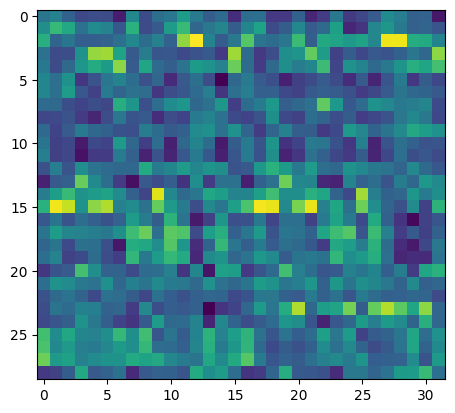

In [23]:
plt.imshow(model_task.emissions[0].V)

([<matplotlib.axis.YTick at 0x173b12610>,
 [Text(0, 0, 'sub-02'),
  Text(0, 1, 'sub-03'),
  Text(0, 2, 'sub-06'),
  Text(0, 3, 'sub-08'),
  Text(0, 4, 'sub-10'),
  Text(0, 5, 'sub-12'),
  Text(0, 6, 'sub-14'),
  Text(0, 7, 'sub-18'),
  Text(0, 8, 'sub-20'),
  Text(0, 9, 'sub-22'),
  Text(0, 10, 'sub-24'),
  Text(0, 11, 'sub-25'),
  Text(0, 12, 'sub-26'),
  Text(0, 13, 'sub-27'),
  Text(0, 14, 'sub-28'),
  Text(0, 15, 'sub-30'),
  Text(0, 16, 'sub-31')])

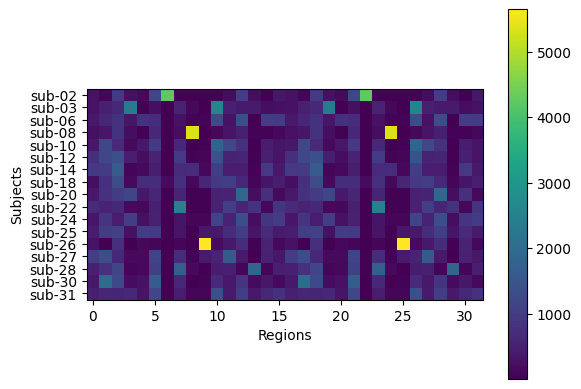

In [18]:
plt.imshow(indiv_par_task.sum(axis=2))
plt.xlabel('Regions')
plt.ylabel('Subjects')
plt.colorbar()
# set ytick labels
plt.yticks(np.arange(len(rest_subjects)), rest_subjects)


## Resting-state data

### Type: Net67Run

In [ ]:
pass

In [68]:
# Step 4b.1: Load the data into 3d tensor
data67, info67, tds = ds.get_dataset(data_dir, 'MDTB', atlas=space.name, sess='ses-rest', type='Net67Run', subj=rest_subjects)

# Step 4b.2: Prepare the data into the right format
tdata67, cond_v67, part_v67, sub_ind_v67 = fm.prep_datasets(data67, info67.sess,
                                                  info67['net_id'].values,
                                                  info67['half'].values,
                                                  join_sess=False,
                                                  join_sess_part=False)

In [24]:
indiv_par_rest_net67, _, model_rest67 = fm.get_indiv_parcellation(ar_model, space, tdata67, cond_v67, part_v67, sub_ind_v67, Vs=None, sym_type = sym_type)

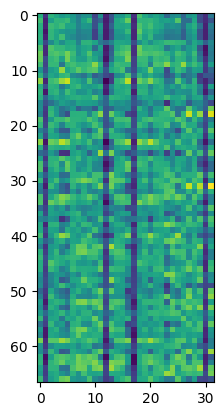

In [25]:
plt.imshow(model_rest67.emissions[0].V)

# HCP Vs

In [27]:
# Step 4b.1: Load the data into 3d tensor
hcp, hcp_info, hcp_tds = ds.get_dataset(data_dir, 'HCP', atlas=space.name, type='Net67Run')

# Step 4b.2: Prepare the data into the right format
tdata_hcp, cond_v_hcp, part_v_hcp, sub_ind = fm.prep_datasets(hcp, hcp_info.sess,
                                                  hcp_info['net_id'].values,
                                                  hcp_info['half'].values,
                                                  join_sess=False,
                                                  join_sess_part=False)

In [28]:
indiv_par_res_hcp, _, model_hcp = fm.get_indiv_parcellation(ar_model, space, tdata_hcp, cond_v_hcp, part_v_hcp, sub_ind, Vs=None, sym_type = sym_type)

/Users/callithrix/code/Python/HierarchBayesParcel/full_model.py:354: UserWarning: Likelihood decreased - terminating on iteration 84
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


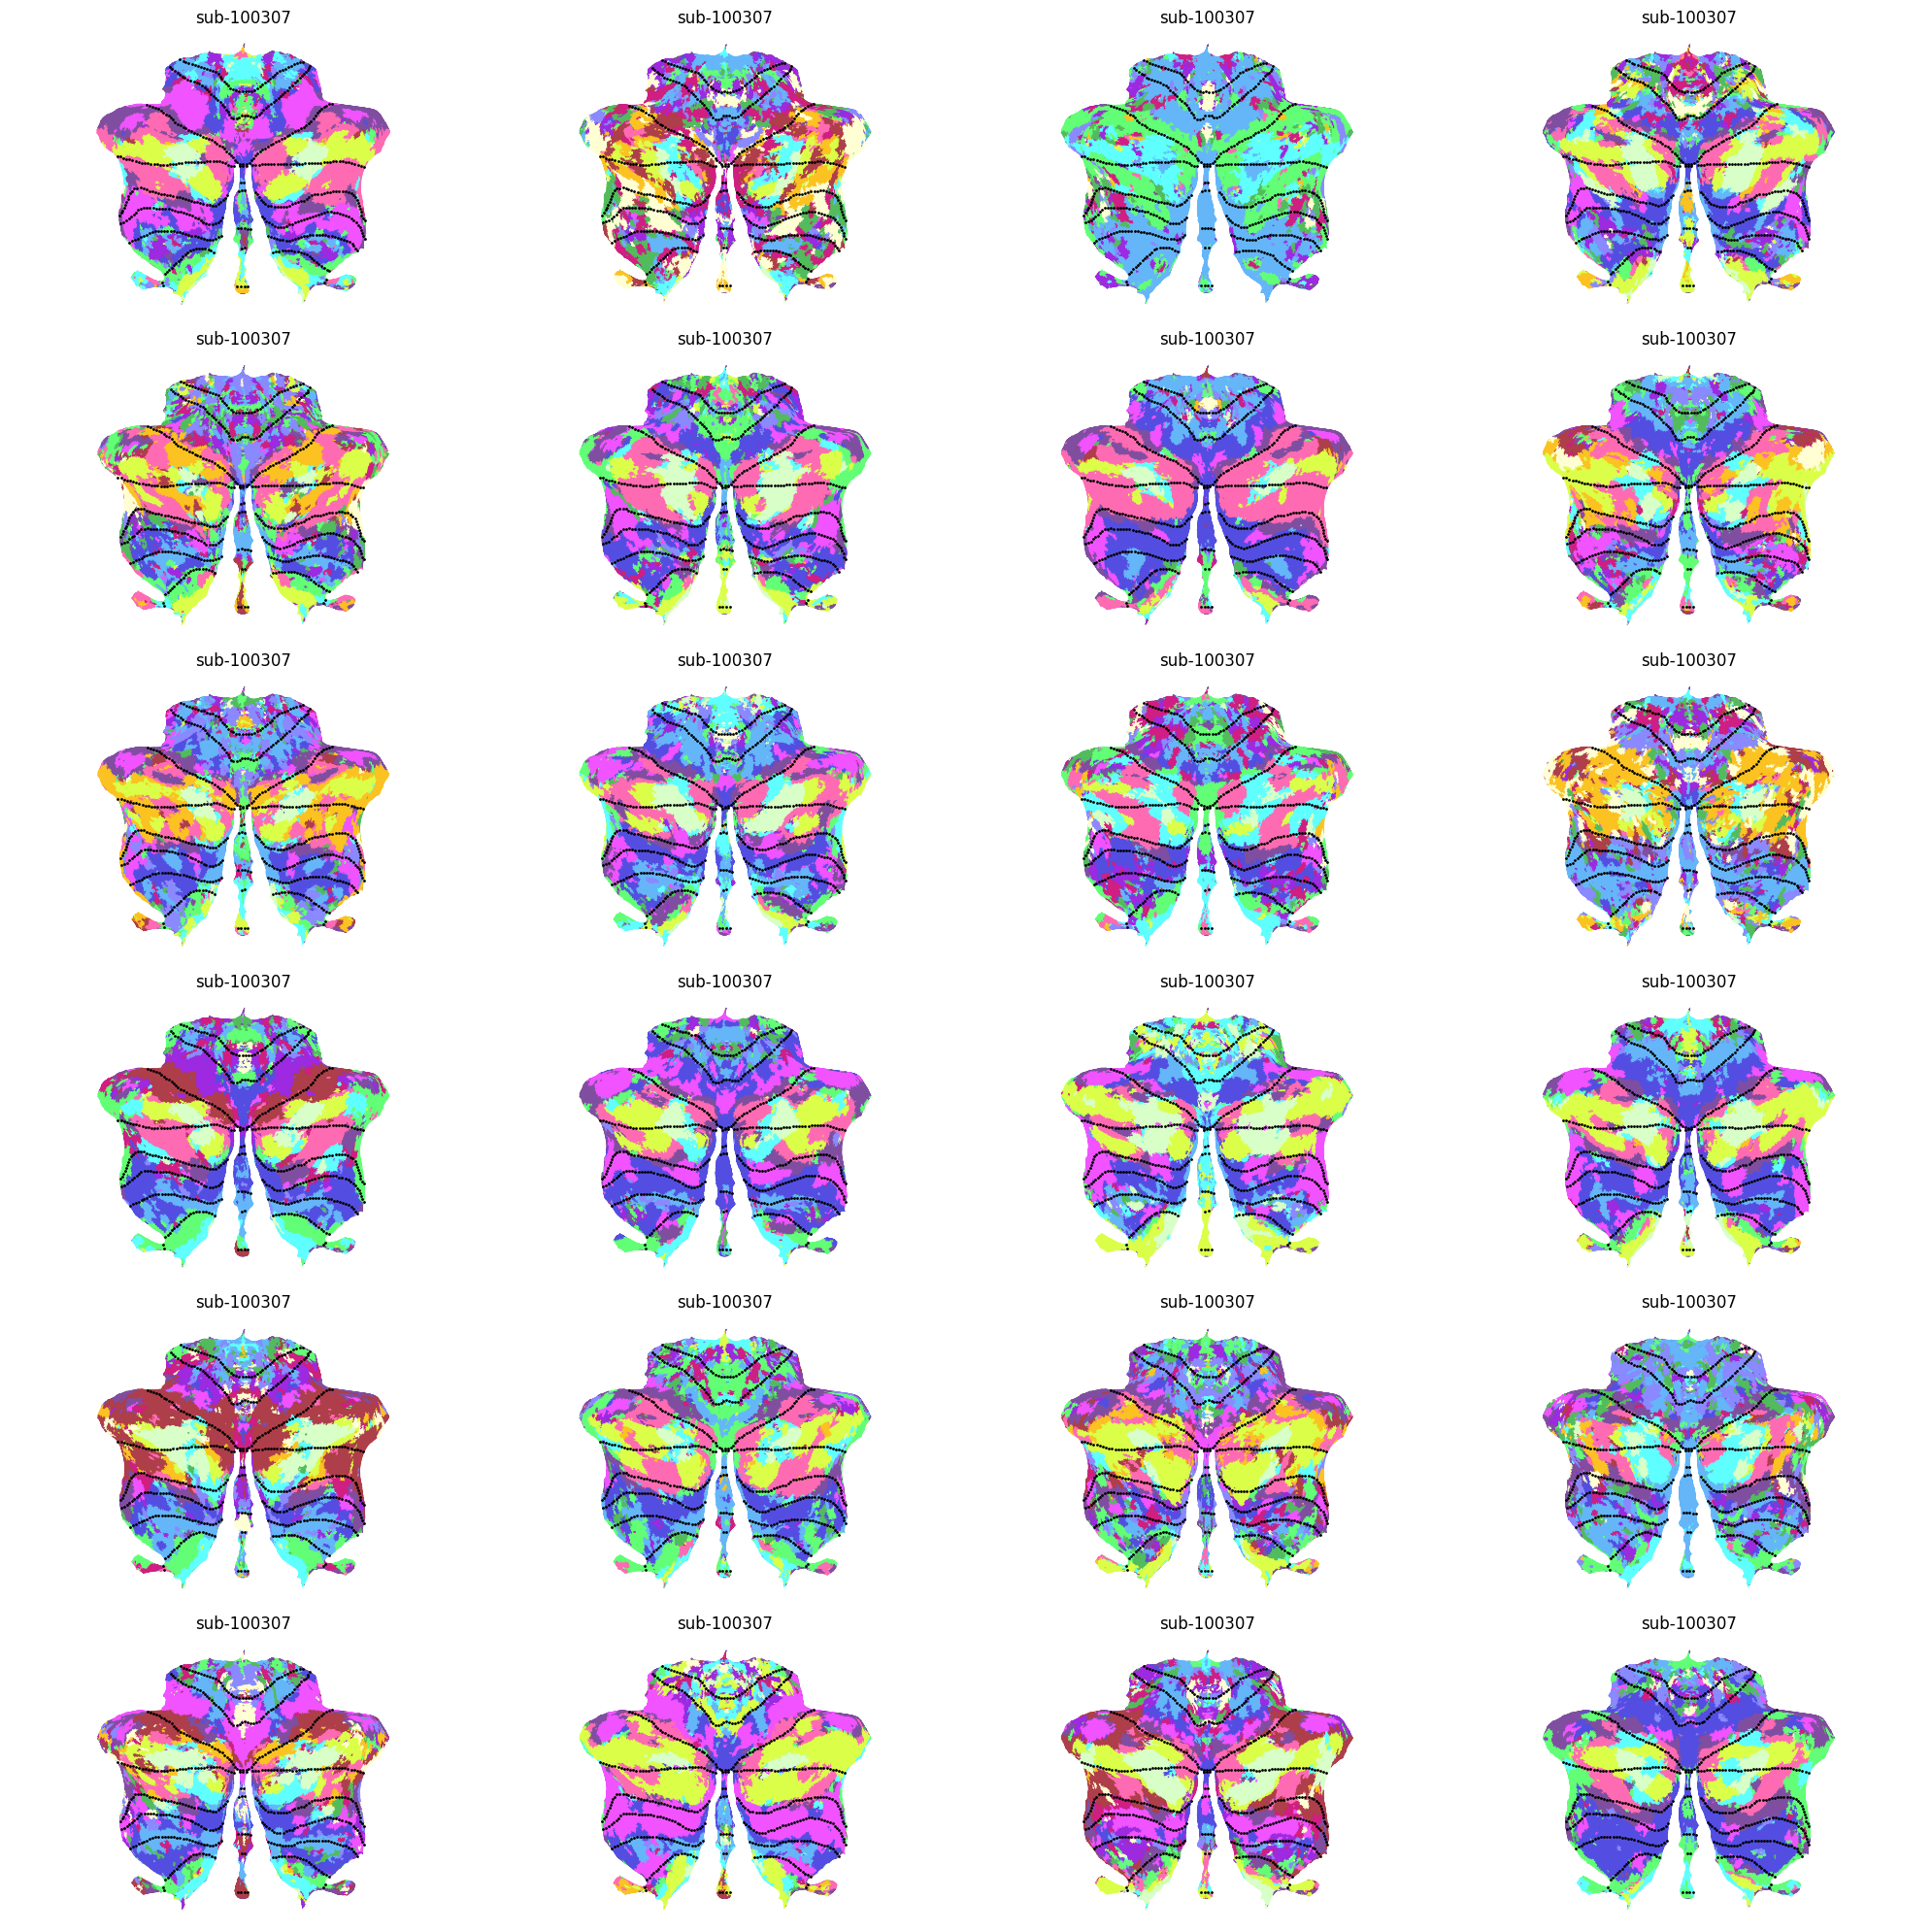

In [42]:
plt.figure(figsize=(20,20))
plot_multi_flat(indiv_par_res_hcp.cpu().numpy()[:6*4,:,:], atlas=space.name, grid=(6, 4),
                titles = [f'sub-{i}' for i in hcp_info['sn'].values[:6*4]],
                cmap=cmap, dtype='prob')

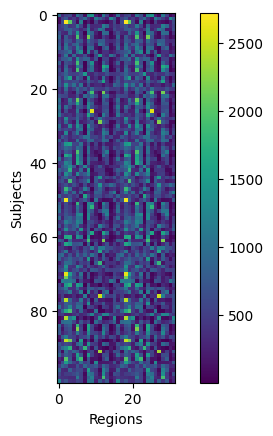

In [64]:
plt.imshow(indiv_par_res_hcp.sum(axis=2))
plt.xlabel('Regions')
plt.ylabel('Subjects')
plt.colorbar()


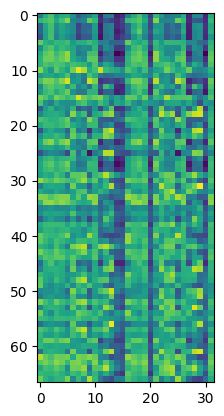

In [35]:
plt.imshow(model_hcp.emissions[0].V)

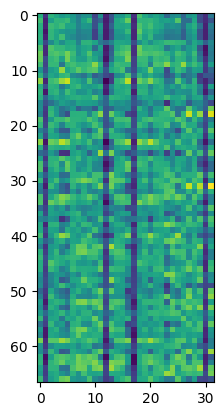

In [34]:
ax2 = plt.imshow(model_rest67.emissions[0].V)


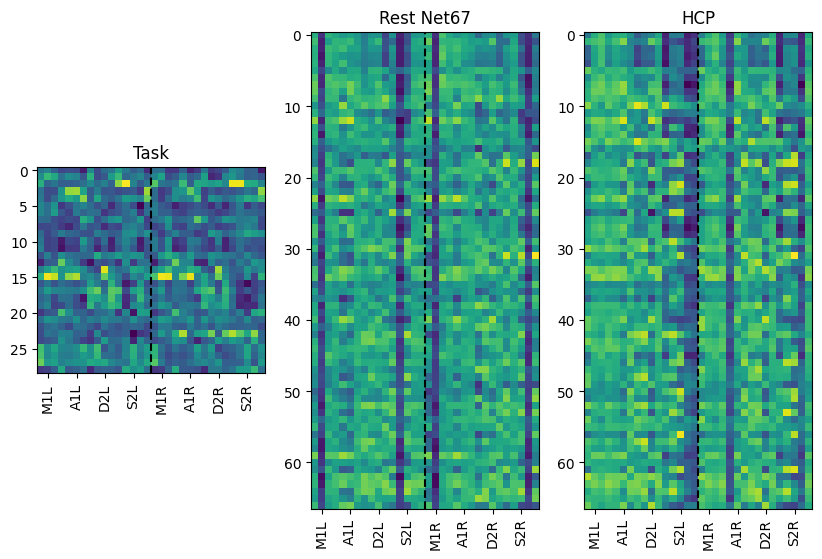

In [86]:
fig, axs = plt.subplots(1, 3, figsize=(10, 30))
# Task
axs[0].imshow(model_task.emissions[0].V)
axs[0].axvline(x=15.5, color='k', linestyle='--')
axs[0].set_xticks(np.arange(32)[1::4])  # Add region label for every fourth tick
axs[0].set_xticklabels(labels[1::4], rotation=90) 
axs[0].set_title('Task')
# Rest Net67
axs[1].imshow(model_rest67.emissions[0].V)
axs[1].axvline(x=15.5, color='k', linestyle='--')
axs[1].set_xticks(np.arange(32)[1::4])  # Add region label for every fourth tick
axs[1].set_xticklabels(labels[1::4], rotation=90) 
axs[1].set_title('Rest Net67')
# HCP
axs[2].imshow(model_hcp.emissions[0].V)
axs[2].axvline(x=15.5, color='k', linestyle='--')
axs[2].set_xticks(np.arange(32)[1::4])  # Add region label for every fourth tick
axs[2].set_xticklabels(labels[1::4], rotation=90) 
axs[2].set_title('HCP')
plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.savefig(f'{figure_dir}/parcellation_Vs.png', dpi=300, bbox_inches='tight')

# Pass Vs to MDTB Rest

In [69]:
indiv_par_rest_net67_vs, _, model_rest67_vs = fm.get_indiv_parcellation(ar_model, space, tdata67, cond_v67, part_v67, sub_ind_v67, Vs=[model_hcp.emissions[0].V], sym_type = sym_type)

/Users/callithrix/code/Python/HierarchBayesParcel/full_model.py:354: UserWarning: Likelihood decreased - terminating on iteration 3
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


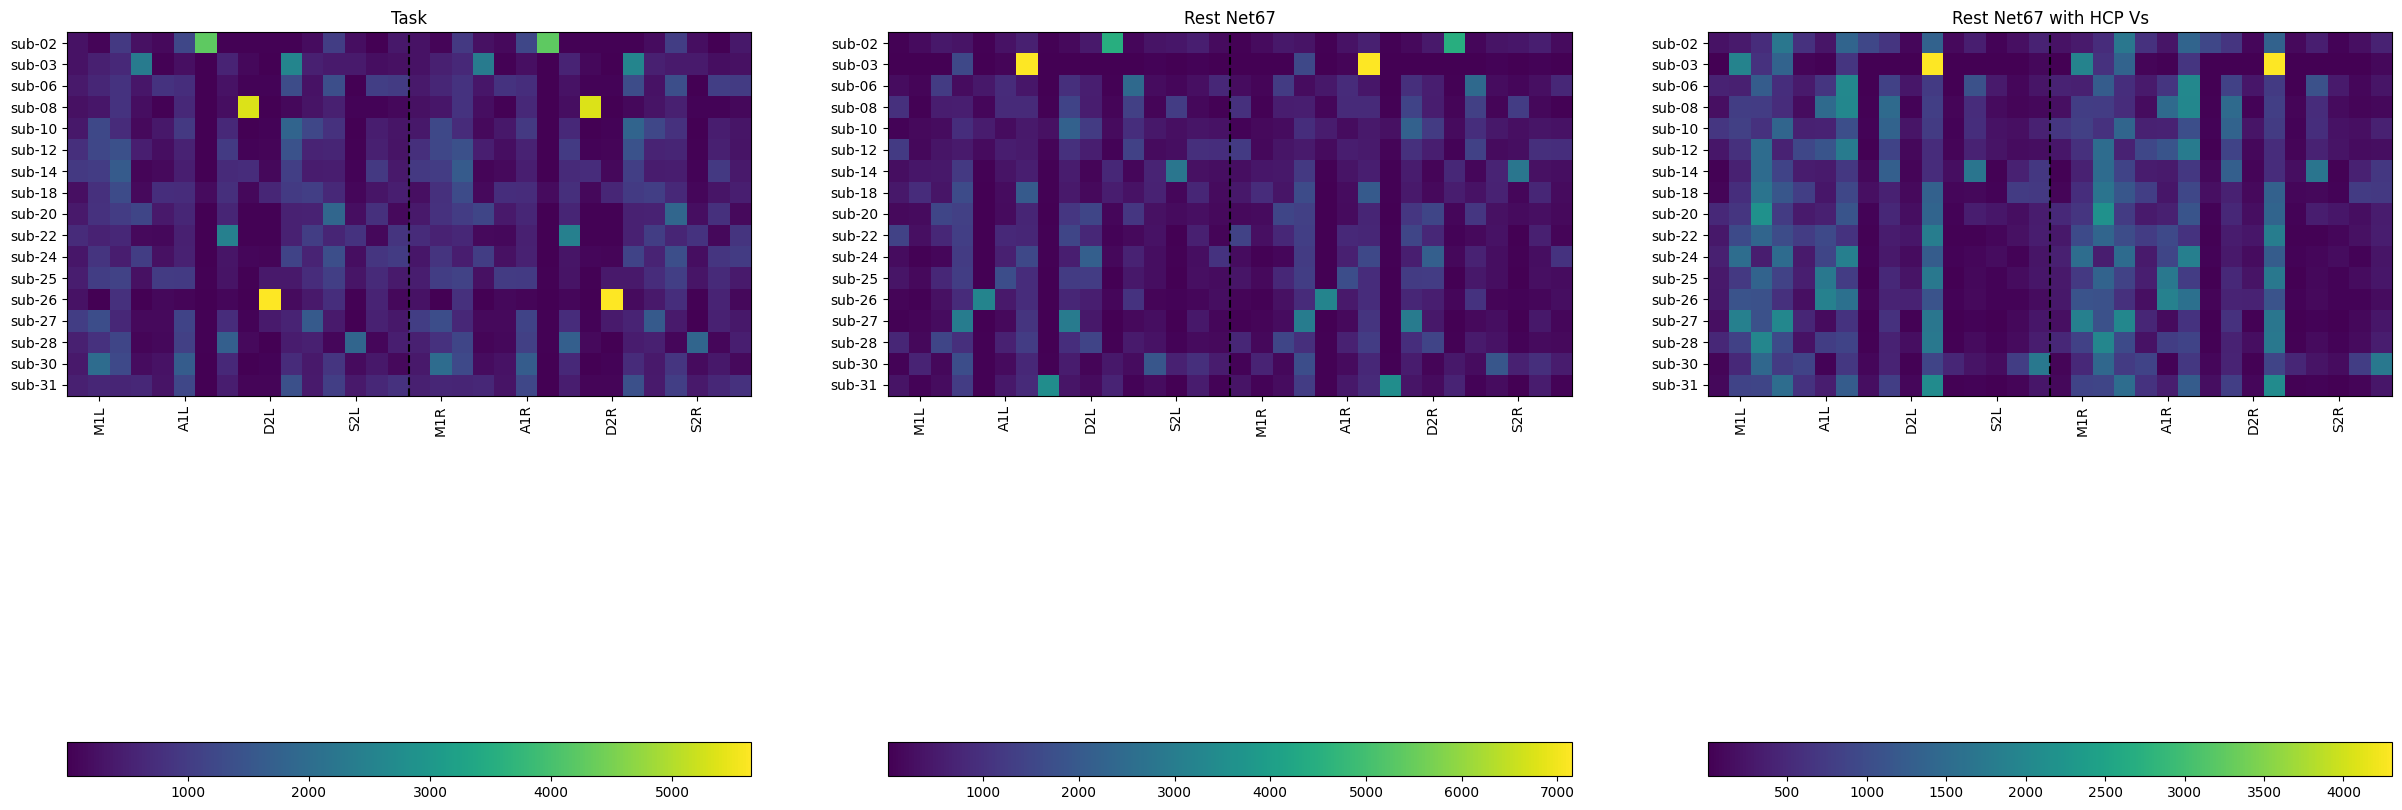

In [106]:
fig, axs = plt.subplots(1, 3, figsize=(30, 30))
# Task
plt.colorbar(axs[0].imshow(indiv_par_task.sum(axis=2)), ax=axs[0], orientation='horizontal')

axs[0].axvline(x=15.5, color='k', linestyle='--')
axs[0].set_xticks(np.arange(32)[1::4])  # Add region label for every fourth tick
axs[0].set_xticklabels(labels[1::4], rotation=90) 
axs[0].set_title('Task')
# Rest Net67
plt.colorbar(axs[1].imshow(indiv_par_rest_net67.sum(axis=2)), ax=axs[1], orientation='horizontal')
axs[1].axvline(x=15.5, color='k', linestyle='--')
axs[1].set_xticks(np.arange(32)[1::4])  # Add region label for every fourth tick
axs[1].set_xticklabels(labels[1::4], rotation=90) 
axs[1].set_title('Rest Net67')
# Rest MDTB with HCP Vs
plt.colorbar(axs[2].imshow(indiv_par_rest_net67_vs.sum(axis=2)), ax=axs[2], orientation='horizontal')
axs[2].axvline(x=15.5, color='k', linestyle='--')
axs[2].set_xticks(np.arange(32)[1::4])  # Add region label for every fourth tick
axs[2].set_xticklabels(labels[1::4], rotation=90)
axs[2].set_title('Rest Net67 with HCP Vs')

# add subject labels (every second label)
for ax in axs:
    ax.set_yticks(np.arange(len(rest_subjects)))  # Add subject label for every tick
    ax.set_yticklabels(rest_subjects)

# axs[0].set_yticks(np.arange(len(rest_subjects)))  # Add subject label for every tick
# axs[0].set_yticklabels(rest_subjects)

# add colorbar horizontally below plot
plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.savefig(f'{figure_dir}/subject_region_influence.png', dpi=300, bbox_inches='tight')


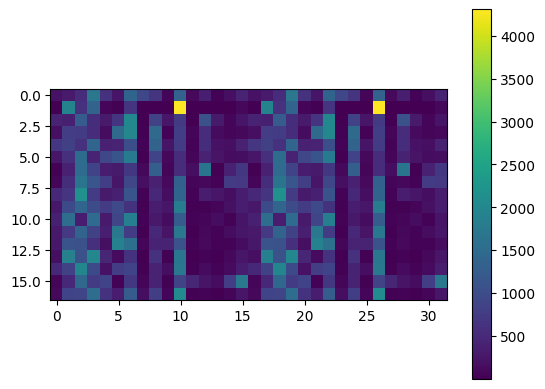

In [73]:
plt.imshow(indiv_par_rest_net67_vs.sum(axis=2))
plt.colorbar()
plt.savefig(f'{figure_dir}/subject_region_influence.png', dpi=300, bbox_inches='tight')

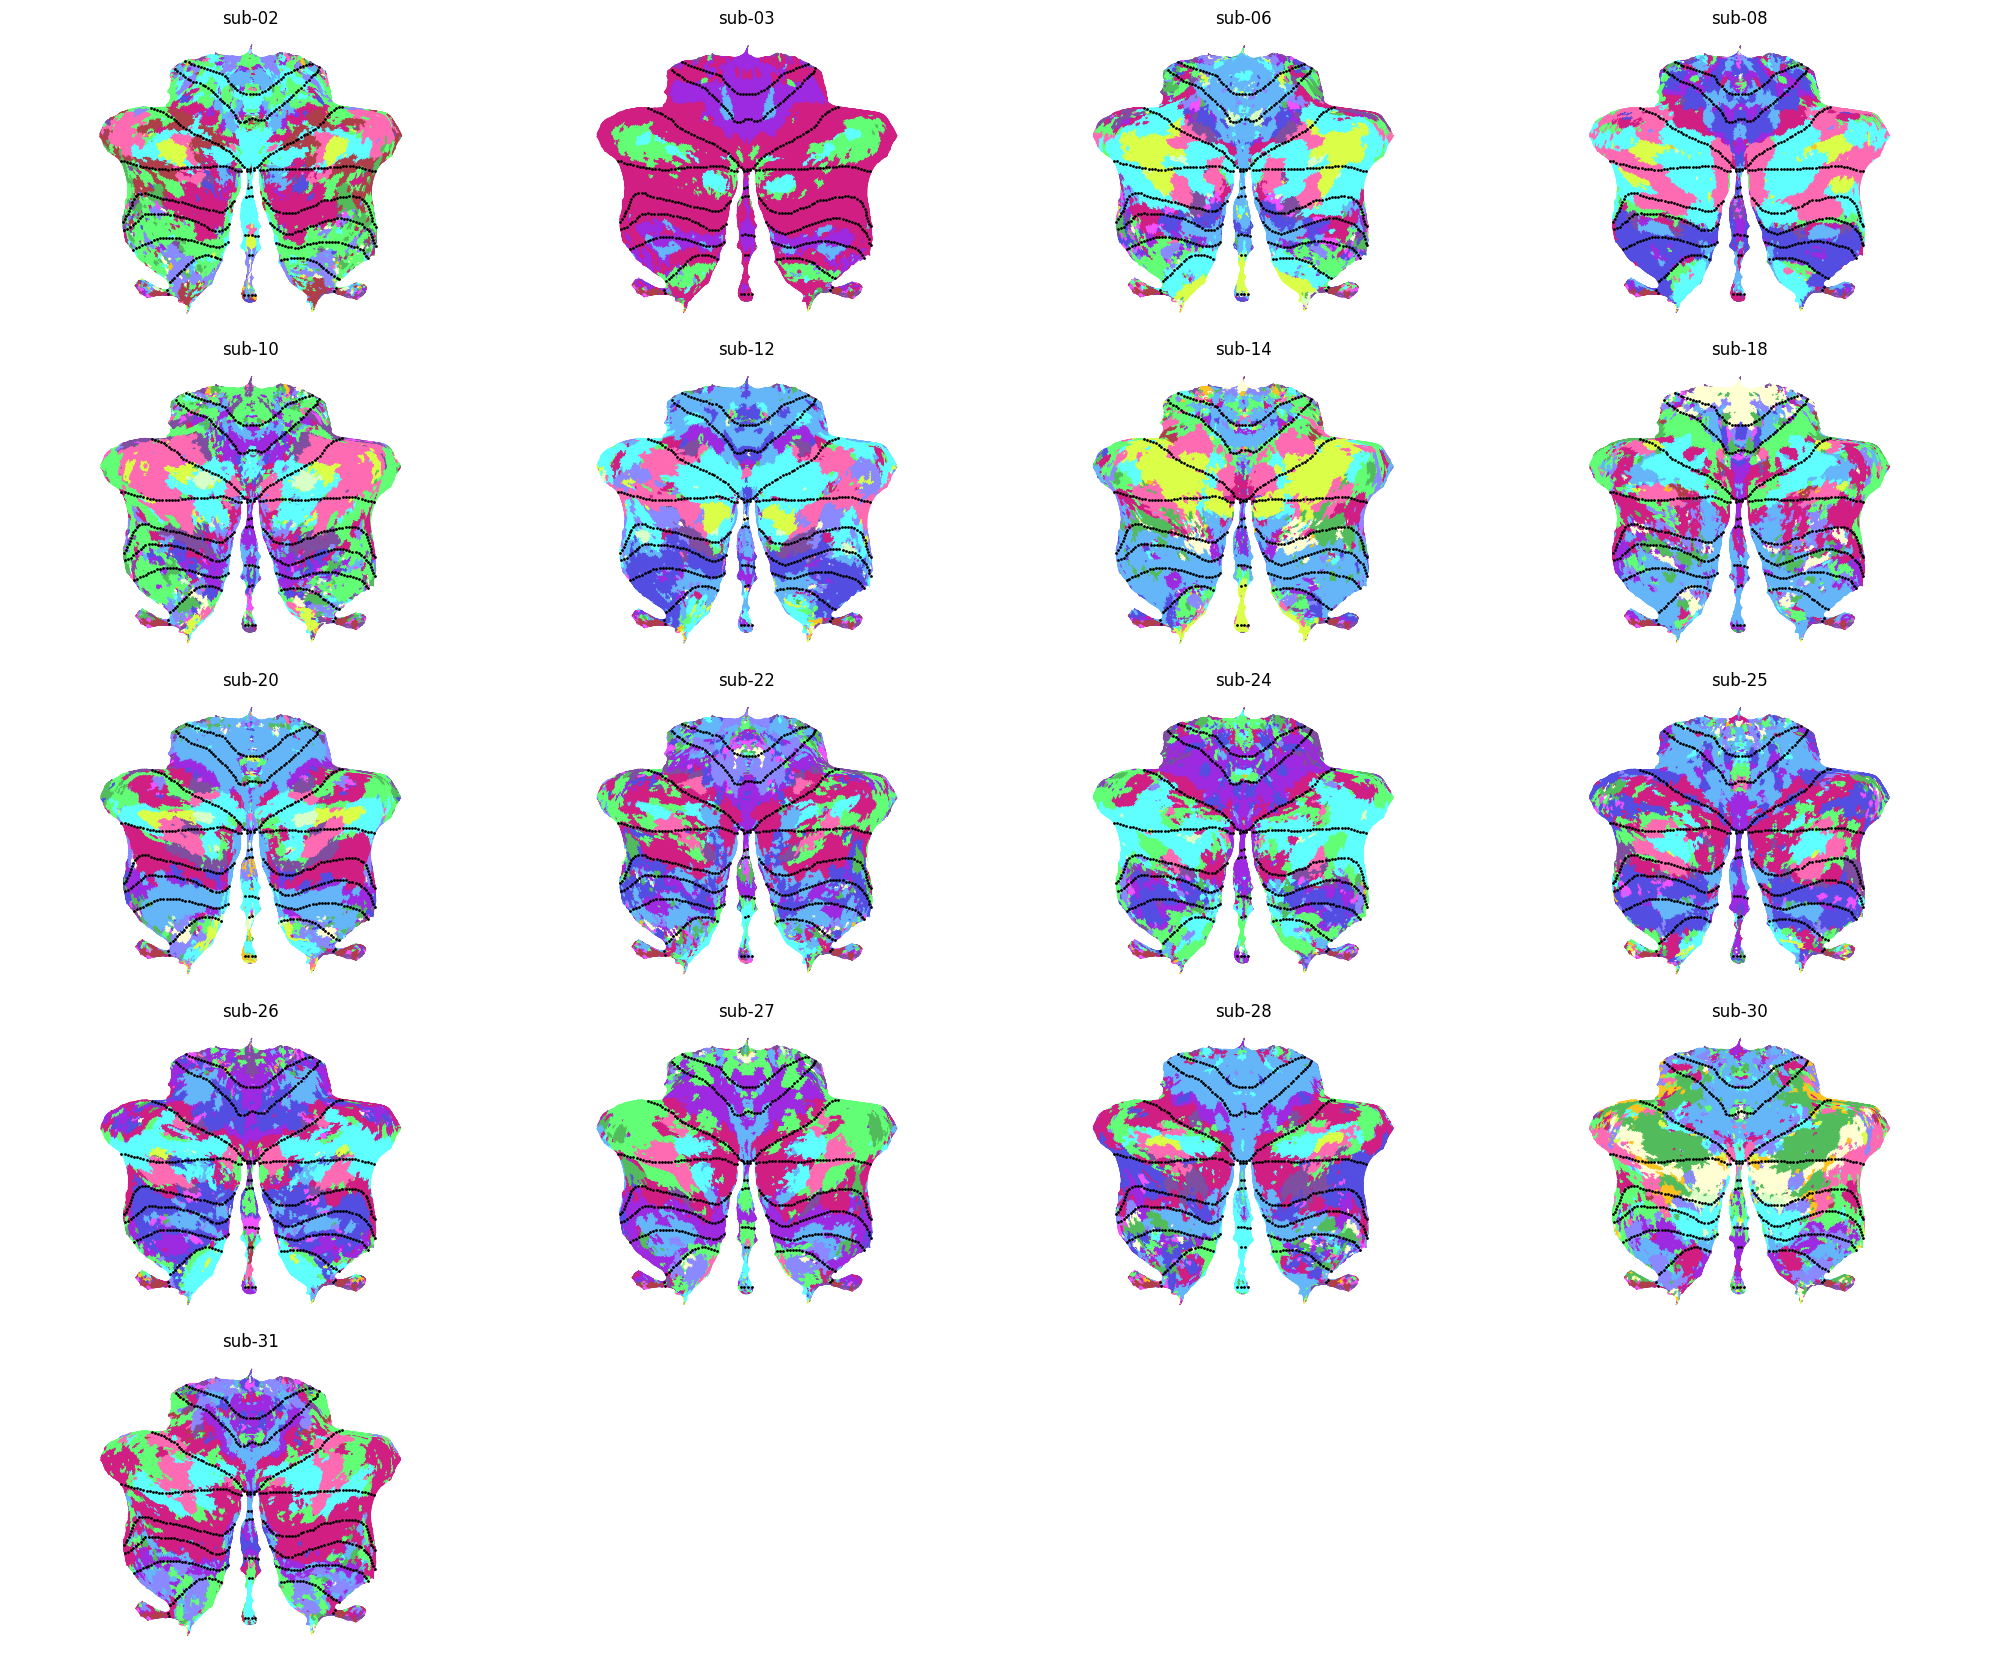

In [108]:
plt.figure(figsize=(20,20))
plot_multi_flat(indiv_par_rest_net67_vs.cpu().numpy(), atlas=space.name, grid=(6, 4),
                cmap=cmap, dtype='prob',
                titles=rest_subjects)
plt.savefig(f'{figure_dir}/indiv_par_rest_net67_hcpVs.png', dpi=300, bbox_inches='tight')

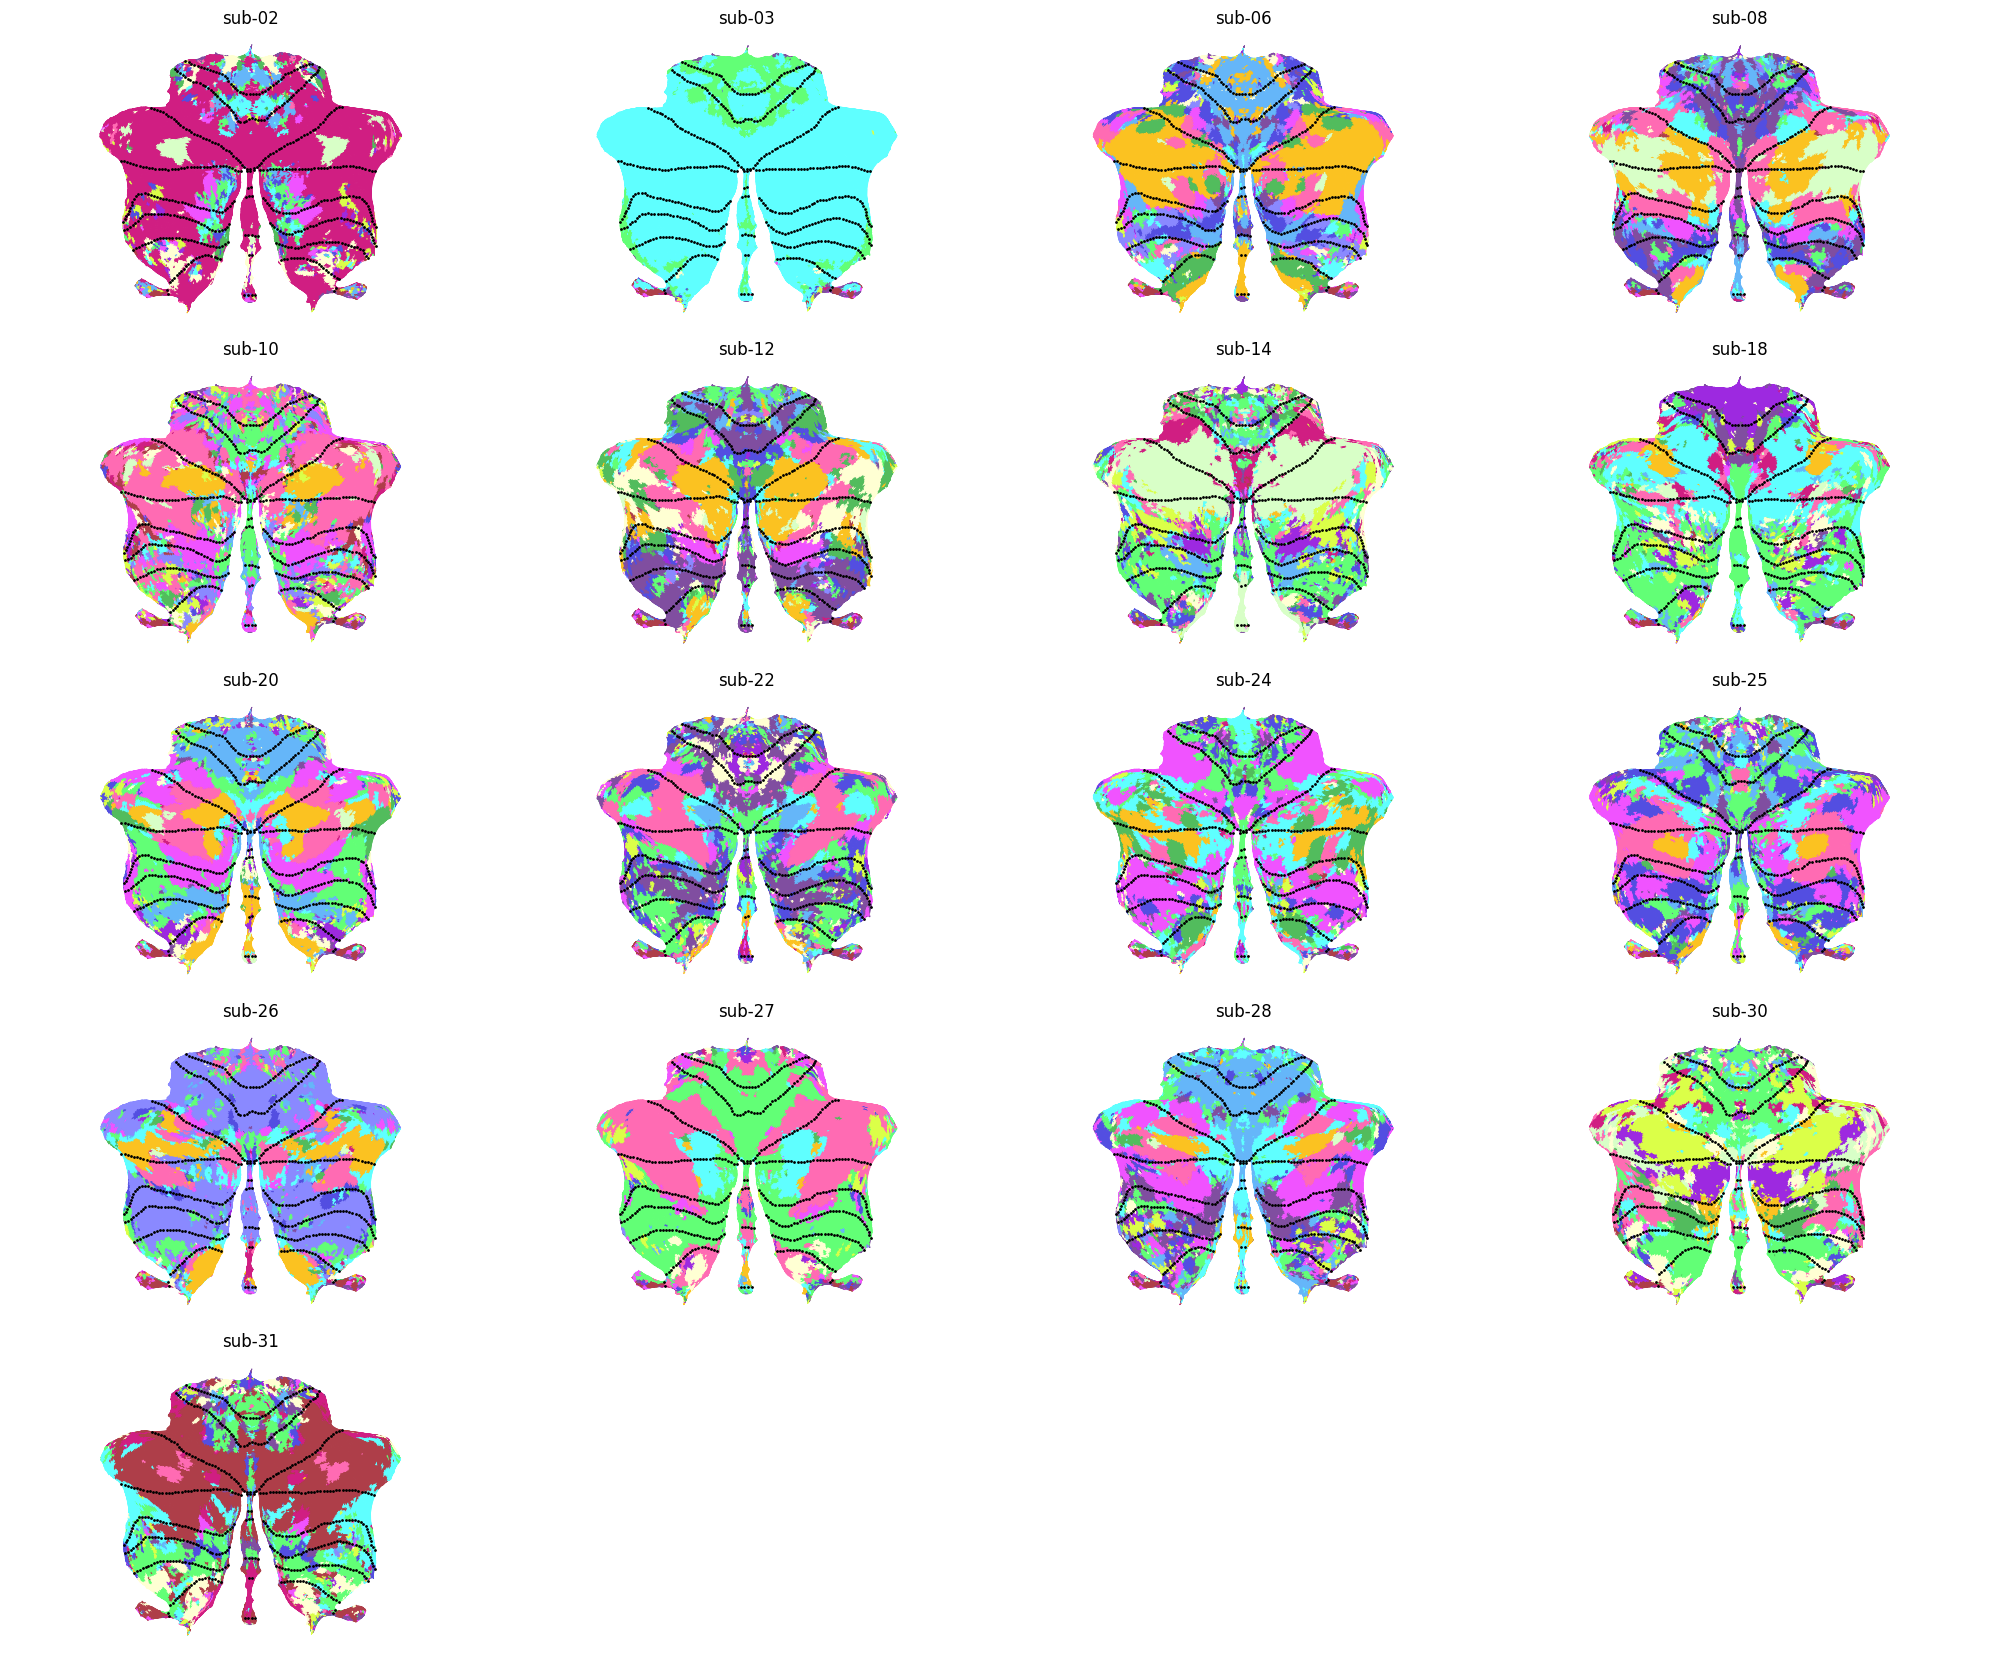

In [109]:
plt.figure(figsize=(20,20))
plot_multi_flat(indiv_par_rest_net67.cpu().numpy()[:6*4,:,:], atlas=space.name, grid=(6, 4),
                titles=rest_subjects,
                cmap=cmap, dtype='prob')
plt.savefig(f'{figure_dir}/indiv_par_rest_net67.png', dpi=300, bbox_inches='tight')

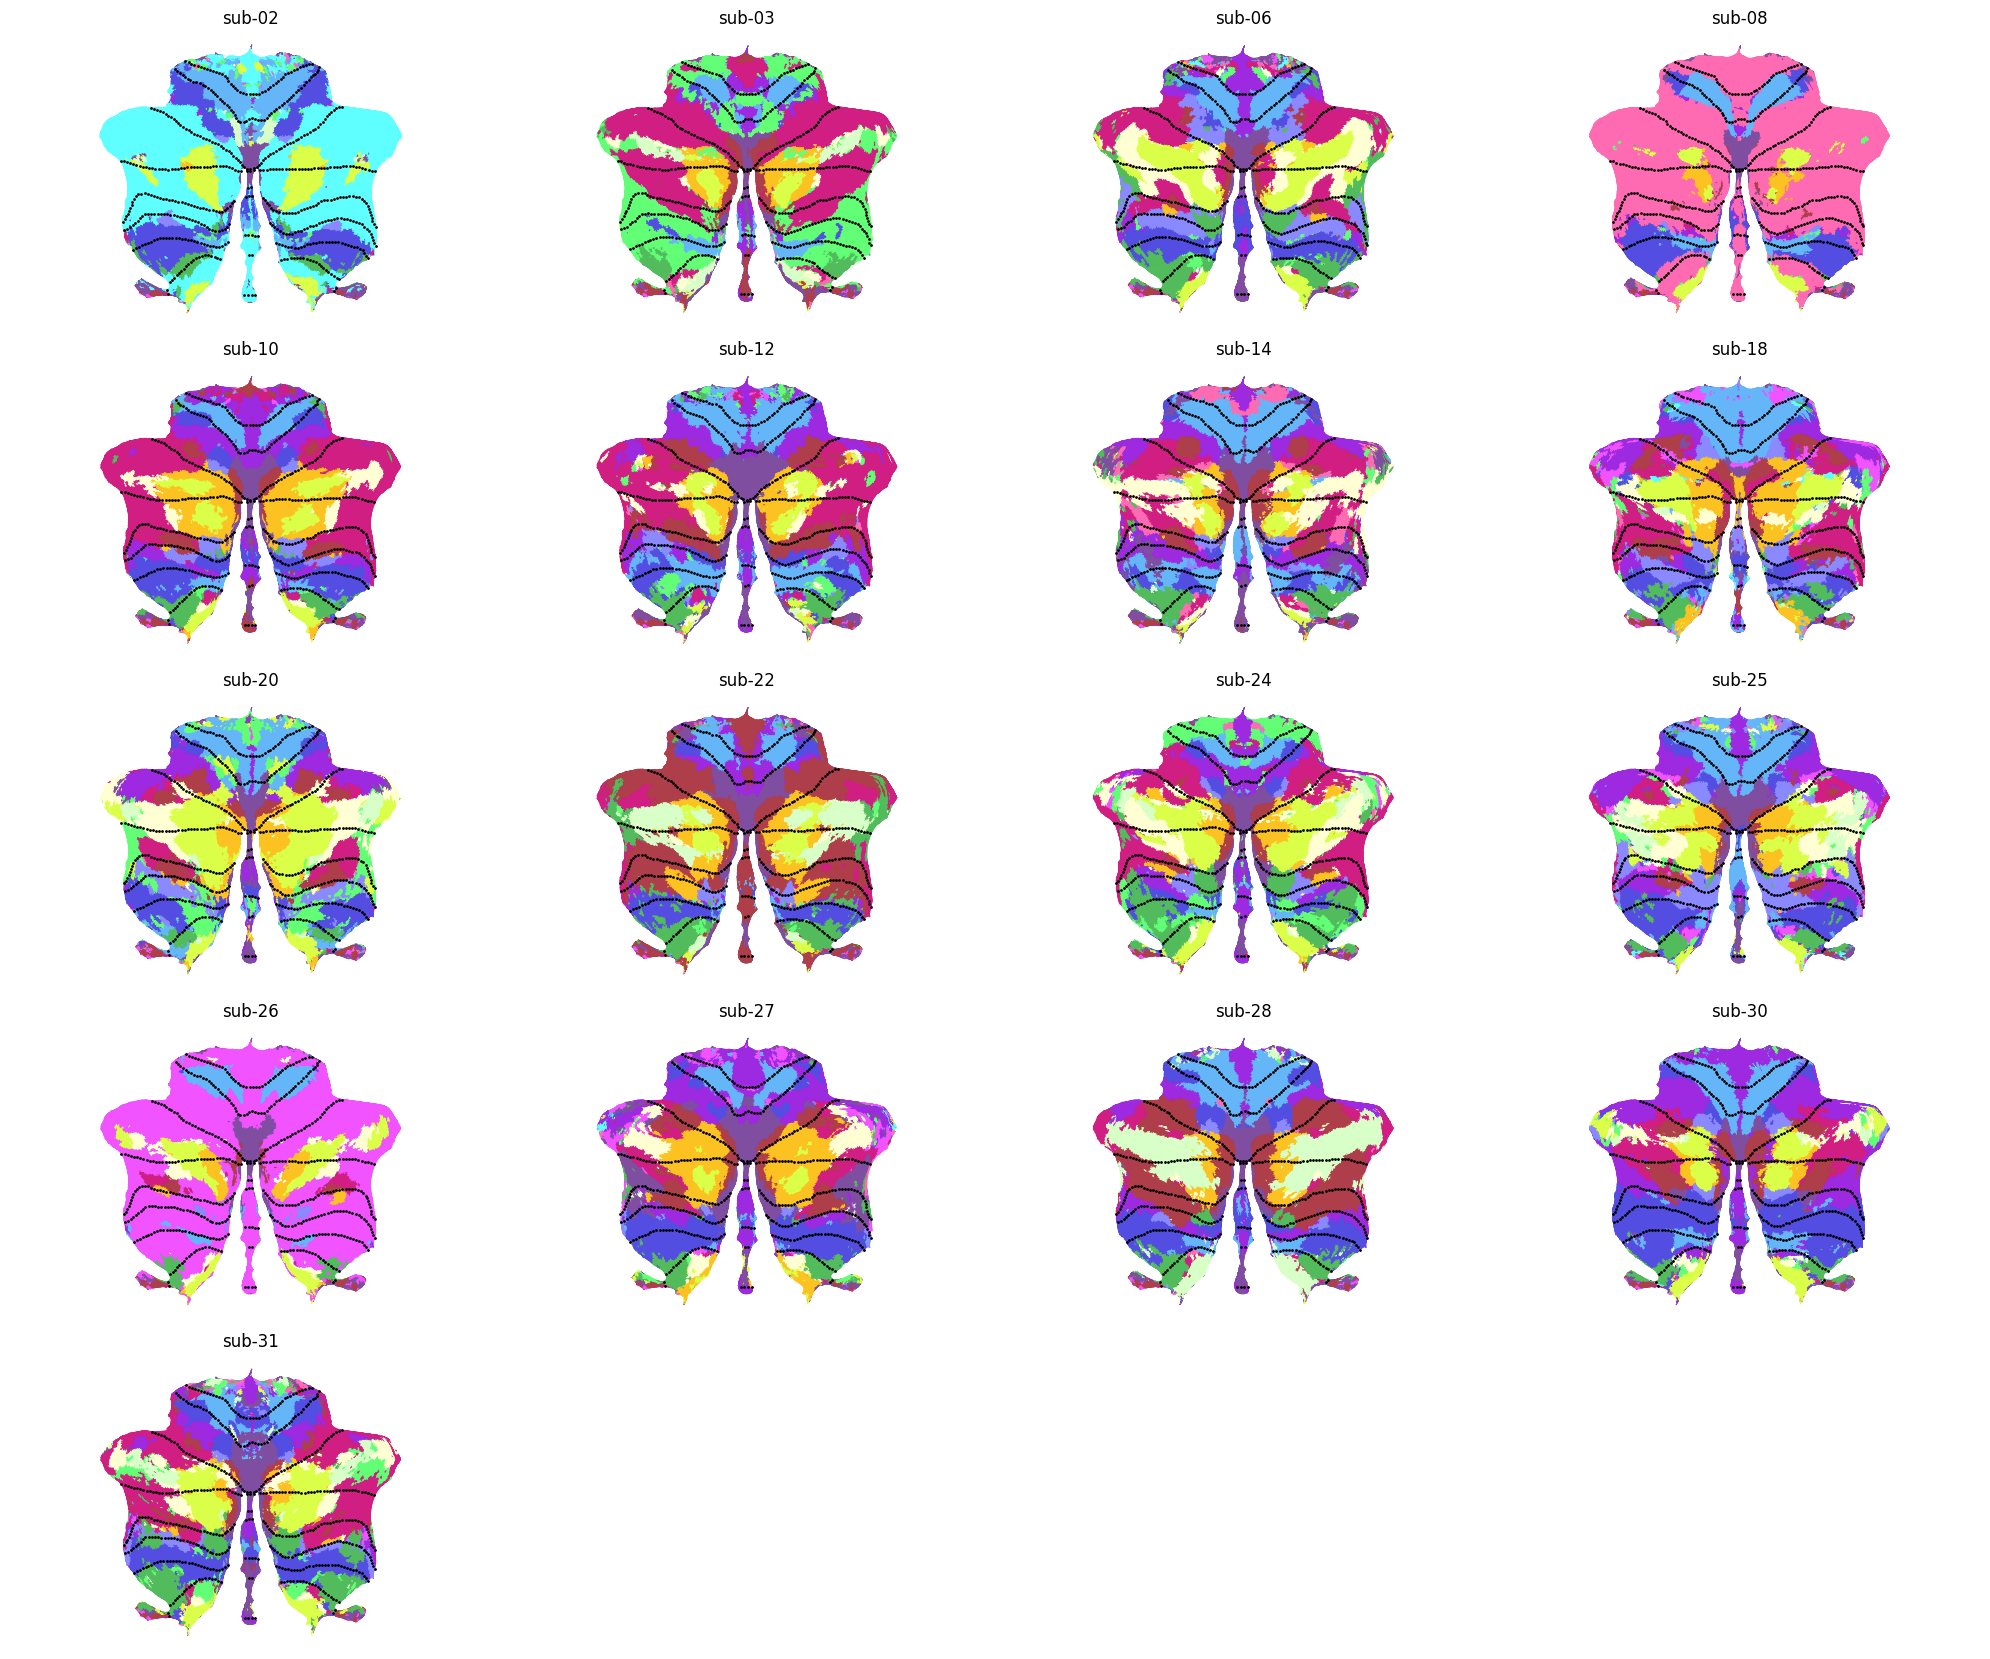

In [110]:
plt.figure(figsize=(20,20))
plot_multi_flat(indiv_par_task.cpu().numpy()[:6*4,:,:], atlas=space.name, grid=(6, 4),
                titles=rest_subjects,
                cmap=cmap, dtype='prob')
plt.savefig(f'{figure_dir}/indiv_par_task.png', dpi=300, bbox_inches='tight')